In [1]:
!pip install torchcfm torchdyn -q

In [2]:
%load_ext autoreload
%autoreload 2
import os
import time

import wandb
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
import torchdiffeq
import torchsde
from torchdyn.core import NeuralODE
from torchvision import datasets, transforms
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models.unet import UNetModel
import torch.nn as nn 
from torchcfm.models.unet.unet import timestep_embedding

savedir = "models/cond_mnist"
train_dir = "../data"
os.makedirs(savedir, exist_ok=True)

In [3]:
@dataclass
class Config:
    sigma: float = 0.0
    epochs: int = 10
    batch_size: int = 64
    num_channels: int = 32
    num_res_blocks: int = 1
    cond_dim: int = 2
    lr: float = 1e-4
    solver: str = "dopri5"
    sample_freq: int = 5
    dim: tuple = (1,28,28)
cfg = Config()

In [4]:
# import os
# wandb.login(key=os.environ["WANDB_API_KEY"])

# # Modell speichern
# savedir = "/kaggle/working/models/cond_mnist"
# train_dir = "/kaggle/working/data"

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

trainset = datasets.MNIST(
    train_dir,
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]),
)

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=cfg.batch_size, shuffle=True, drop_last=True
)


In [6]:
class CFMUNet(UNetModel):
    def __init__(self, cond_dim, **kwargs):
        super().__init__(**kwargs)
        time_embed_dim = kwargs["num_channels"] * 4
        self.label_emb = nn.Sequential(
            nn.Linear(cond_dim, 64),
            nn.SiLU(),
            nn.Linear(64, time_embed_dim)
        )


    def forward(self, t, x, y=None):
        timesteps = t
        while timesteps.dim() > 1:
            timesteps = timesteps[:, 0]
        if timesteps.dim() == 0:
            timesteps = timesteps.repeat(x.shape[0])

        hs = []
        emb = self.time_embed(timestep_embedding(timesteps, self.model_channels))

        if self.num_classes is not None:
            assert y is not None
            emb = emb + self.label_emb(y)  # y: (batch, cond_dim) float

        h = x.type(self.dtype)
        for module in self.input_blocks:
            h = module(h, emb)
            hs.append(h)
        h = self.middle_block(h, emb)
        for module in self.output_blocks:
            h = torch.cat([h, hs.pop()], dim=1)
            h = module(h, emb)
        h = h.type(x.dtype)
        return self.out(h)

In [7]:
# Class-conditional FM
wandb.init(project="DL-Seminar",config=cfg.__dict__)

model = CFMUNet(
    dim=cfg.dim, num_channels=cfg.num_channels, num_classes=10, num_res_blocks=cfg.num_res_blocks, class_cond=True, cond_dim=cfg.cond_dim
).to(device)
FM = ConditionalFlowMatcher(sigma=cfg.sigma)
node = NeuralODE(model, solver=cfg.solver, sensitivity="adjoint", rtol=1e-4, atol=1e-4)
optimizer = torch.optim.AdamW(model.parameters())

angles = 2 * torch.pi * torch.arange(10) / 10
class_embed_2d = torch.stack([torch.cos(angles), torch.sin(angles)],dim=1).to(device)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/hannesneumann/.netrc.
wandb: Currently logged in as: hneumann (hneumann-university-of-mannheim) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [8]:
for epoch in range(cfg.epochs):
    for i, data in tqdm(enumerate(train_loader)):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y_int = data[1]
        y = class_embed_2d[y_int]
        x0 = torch.randn_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

        vt = model(t, xt, y)

        loss = torch.mean((vt - ut)**2)

        loss.backward()
        optimizer.step()
        wandb.log({"loss": loss.item(), "epoch":epoch, "step": i})
    
    if (epoch +1) % cfg.sample_freq == 0:  # alle 5 Epochen
        model.eval()
        with torch.no_grad():
            traj = torchdiffeq.odeint(
                lambda t, x: model(t, x, class_embed_2d[torch.arange(10, device=device).repeat_interleave(10)]),
                torch.randn(100, 1, 28, 28, device=device),
                torch.linspace(0, 1, 2, device=device),
                method="euler",          # euler reicht zum Loggen, spart Zeit
                options={"dtype": torch.float32}
            )
        grid = make_grid(traj[-1].clip(-1, 1), value_range=(-1, 1), nrow=10)
        wandb.log({"samples": wandb.Image(grid), "epoch": epoch})
        model.train()
now = time.time()
path = f"models/cond_mnist/cond_mnist_{epoch}_{now}"
torch.save(model, path)
print(f"Saved Model to {path}")
wandb.finish()

937it [03:37,  4.30it/s]
937it [03:38,  4.30it/s]
937it [03:55,  3.98it/s]
937it [04:14,  3.69it/s]
937it [04:05,  3.82it/s]
/Users/hannesneumann/Repositories/seminar/.venv/lib/python3.13/site-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Euler: Unexpected arguments {'dtype': torch.float32}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))
wandb: WARNING Data passed to `wandb.Image` should consist of values in the range [0, 255], image data will be normalized to this range, but behavior will be removed in a future version of wandb.
937it [04:13,  3.70it/s]
937it [04:19,  3.61it/s]
937it [04:24,  3.54it/s]
937it [04:18,  3.62it/s]
937it [20:10,  1.29s/it] 
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Saved Model to models/cond_mnist/cond_mnist_9_1780560376.163405


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇██████
loss,█▇▄▅▅▃▄▅▅▃▄▄▄▄▄▅▄▁▃▆▄▅▆▃▄▄▅▄▄▅▄▂▃▅▃▁▃▂▄▃
step,▂▂▄▆▂▄▅▇▁▂▃▃▅▅█▃▄▄▆▆▁▄▇▇▄▆▇▁▄▅▇▅▇▂▂▃▅▅▇█
epoch,9
loss,0.15584
step,936


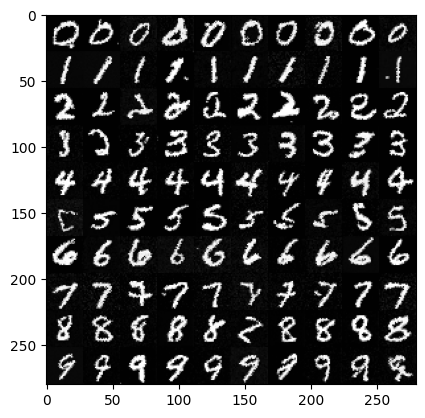

In [9]:
USE_TORCH_DIFFEQ = True

# model = torch.load("models/cond_mnist/cond_mnist_9_1780523305.9501061", weights_only=False).to(device)
# generated_class_list = torch.arange(10, device=device).repeat_interleave(10)
# generated_class_list = torch.asarray().to(device)
# generated_class_list = torch.zeros(100, dtype=torch.long ,device=device)  # nur Nullen
generated_class_list_idx = torch.arange(10, device=device).repeat_interleave(10)
generated_class_list = class_embed_2d[generated_class_list_idx]  # (100, 2) float
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 28, 28, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
            options={"dtype": torch.float32}
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 28, 28, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.show()